# 02. Circuit Validation

        This notebook demonstrates the **causal validation phase**.

        Discovery tells us where to look. Validation asks a stricter question:
        - If we remove or replace part of the model state, does the decision actually change?

        In mechanistic terms, this notebook focuses on:
        - **head ablation** for necessity
        - **activation/path patching** for sufficiency
        - comparison between a minimal direct route and a broader late carrier

        In plain language:
        - What parts of the model are actually doing causal work?
        - Which parts are just nearby or correlated?


In [1]:
from pathlib import Path
import math
import textwrap

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use("ggplot")
sns.set_context("talk")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)


def find_project_root() -> Path:
    candidates = [Path.cwd()] + list(Path.cwd().parents)
    for candidate in candidates:
        if (candidate / "artifacts").exists() and (candidate / "scaled_validation.py").exists():
            return candidate
        if (candidate / "mech-interp-circuit" / "artifacts").exists():
            return candidate / "mech-interp-circuit"
    raise FileNotFoundError("Could not find mech-interp-circuit project root from the current working directory.")


PROJECT_ROOT = find_project_root()
ARTIFACTS = PROJECT_ROOT / "artifacts"
print("Project root:", PROJECT_ROOT)
print("Artifacts dir:", ARTIFACTS)


def read_csv(name: str) -> pd.DataFrame:
    path = ARTIFACTS / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def show_barh(df, label_col, value_col, *, title, xlabel, color="#2B6CB0", sort=True):
    plot_df = df.copy()
    if sort:
        plot_df = plot_df.sort_values(value_col, ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(plot_df))))
    ax.barh(plot_df[label_col], plot_df[value_col], color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    return fig, ax


Project root: /home/ryan/mech-interp-circuit-validation/mech-interp-circuit
Artifacts dir: /home/ryan/mech-interp-circuit-validation/mech-interp-circuit/artifacts


## Step 1: Load the core validation artifacts

        We use:
        - root-head patch and ablation summaries on the 18-pair overlap-controlled cohort
        - grouped late-route patching and ablation summaries on the expanded 96-pair cohort


In [2]:
root_patch = read_csv("circuit_val_batch_causal_root_l4_n18short_h100_patch_summary.csv")
root_ablate = read_csv("circuit_val_batch_causal_root_l4_n18short_h100_ablation_summary.csv")

route_minimal = read_csv("circuit_val_path_patching_h011_plus_l12_top3_combo96_h100_summary.csv")
route_top5 = read_csv("circuit_val_path_patching_l12_writer_top5_combo96_h100_summary.csv")
route_minus_h2 = read_csv("circuit_val_path_patching_l12_writer_minus_h2_combo96_h100_summary.csv")
route_minus_h28 = read_csv("circuit_val_path_patching_l12_writer_minus_h28_combo96_h100_summary.csv")
ablate_h28 = read_csv("circuit_val_head_group_ablation_l12_writer_h28_combo96_h100_summary.csv")

root_ablate


,layer,head,pair_count,mean_delta,max_delta,min_delta,flip_rate
0,0,11,18,-0.300618,0.009766,-0.560547,0.944444
1,0,9,18,-0.282606,0.061523,-0.698242,0.944444
2,0,23,18,0.257758,0.383789,0.129883,0.666667
3,0,8,18,0.110433,0.408203,-0.188477,0.611111


## Step 2: Validate the early detector heads by ablation

        In an ablation test, we zero out a head and see whether the final logit difference drops.

        Technical interpretation:
        - a more negative `mean_delta` means the head was helping push the decision toward `BLOCK`

        Plain-language interpretation:
        - if removing the head makes the model less confident that the script is malicious, that head was doing real work


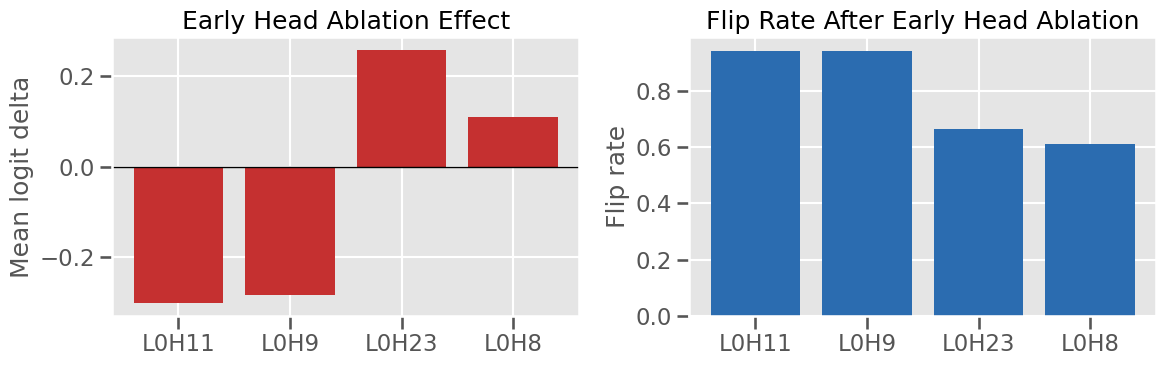

,head_label,mean_delta,flip_rate,pair_count
0,L0H11,-0.300618,0.944444,18
1,L0H9,-0.282606,0.944444,18
2,L0H23,0.257758,0.666667,18
3,L0H8,0.110433,0.611111,18


In [3]:
early = root_ablate.copy()
early["head_label"] = early.apply(lambda row: f"L{int(row['layer'])}H{int(row['head'])}", axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(early["head_label"], early["mean_delta"], color="#C53030")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Early Head Ablation Effect")
axes[0].set_ylabel("Mean logit delta")

axes[1].bar(early["head_label"], early["flip_rate"], color="#2B6CB0")
axes[1].set_title("Flip Rate After Early Head Ablation")
axes[1].set_ylabel("Flip rate")

plt.tight_layout()
plt.show()

early[["head_label", "mean_delta", "flip_rate", "pair_count"]]


## Step 3: Interpret the patching results carefully

        Patching is useful, but in this project it is **not** as clean as ablation for the early heads.
        Why?

        Because the benign control scripts often contain the same suspicious literal strings as the malicious scripts. That means the "clean" source state is not always truly clean in a semantic sense.

        So for the early detector claim:
        - **ablation** is the strongest evidence
        - **patching** is a consistency check, not the main proof


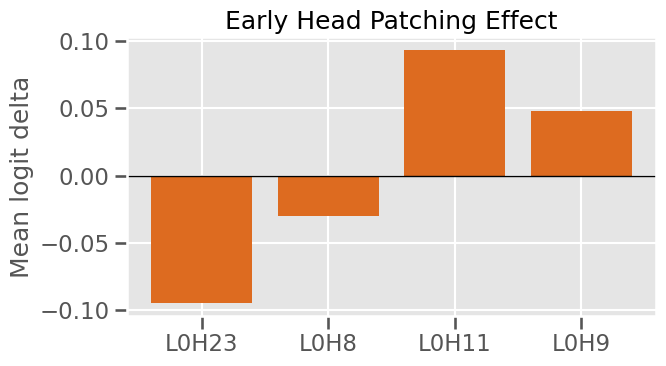

,head_label,mean_delta,flip_rate,pair_count
0,L0H23,-0.094455,0.888889,18
1,L0H8,-0.029867,0.777778,18
2,L0H11,0.093045,0.777778,18
3,L0H9,0.048041,0.722222,18


In [4]:
patch = root_patch.copy()
patch["head_label"] = patch.apply(lambda row: f"L{int(row['layer'])}H{int(row['head'])}", axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(patch["head_label"], patch["mean_delta"], color="#DD6B20")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Early Head Patching Effect")
ax.set_ylabel("Mean logit delta")
plt.tight_layout()
plt.show()

patch[["head_label", "mean_delta", "flip_rate", "pair_count"]]


## Step 4: Compare the candidate late routes on the 96-pair cohort

        This is where the project moved from "there is some late-stage computation" to a more specific claim.

        We compare:
        - the **minimal direct route**: `L0H11 -> L12H15/L12H5/L12H4`
        - the **full top-5 late bundle**
        - leave-one-out variants that test whether `H2` or `H28` are genuinely important


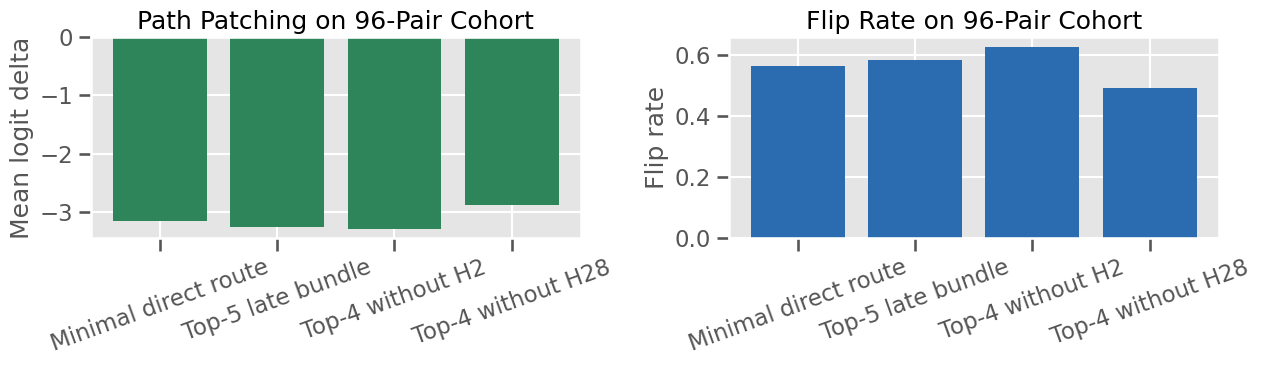

,route,mean_delta,flip_rate
0,Minimal direct route,-3.156087,0.562500
1,Top-5 late bundle,-3.264648,0.583333
2,Top-4 without H2,-3.293132,0.625000
3,Top-4 without H28,-2.885579,0.489583


In [5]:
route_rows = [
    ("Minimal direct route", float(route_minimal["mean_delta"].iloc[0]), float(route_minimal["flip_rate"].iloc[0])),
    ("Top-5 late bundle", float(route_top5["mean_delta"].iloc[0]), float(route_top5["flip_rate"].iloc[0])),
    ("Top-4 without H2", float(route_minus_h2["mean_delta"].iloc[0]), float(route_minus_h2["flip_rate"].iloc[0])),
    ("Top-4 without H28", float(route_minus_h28["mean_delta"].iloc[0]), float(route_minus_h28["flip_rate"].iloc[0])),
]
route_df = pd.DataFrame(route_rows, columns=["route", "mean_delta", "flip_rate"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(route_df["route"], route_df["mean_delta"], color="#2F855A")
axes[0].set_title("Path Patching on 96-Pair Cohort")
axes[0].set_ylabel("Mean logit delta")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(route_df["route"], route_df["flip_rate"], color="#2B6CB0")
axes[1].set_title("Flip Rate on 96-Pair Cohort")
axes[1].set_ylabel("Flip rate")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

route_df


## Step 5: What the validation phase shows

        The cleanest final validation claim is:

        - `L0H11` and `L0H9` are the strongest portable **early causal heads**
        - the cleanest minimal direct route is `L0H11 -> L12H15/L12H5/L12H4`
        - the cleaner sufficiency-oriented late carrier is `L12H15/L12H5/L12H4/L12H28`
        - `L12H2` behaves more like a family-sensitive helper than a stable core writer

        This is why the repo writeup separates:
        - a **minimal direct branch** for mechanistic clarity
        - a **broader late carrier** for stronger sufficiency on the larger cohort


## Optional: Rerun notes

        The commands below are examples only. They are usually more comfortable on GPU, but they document exactly how the validation artifacts were produced.


In [6]:
# Example only. Uncomment to rerun a small validation command.
#
# !python ../scaled_validation.py batch-head-group-ablation \
#     --manifest ../artifacts/circuit_val_pair_manifest_t3000_valid_causal18_short.csv \
#     --heads 12.15,12.5,12.4,12.28 \
#     --device cpu \
#     --torch-dtype float32 \
#     --num-pairs 2 \
#     --allow-zero-indicator-malicious \
#     --output-prefix ../artifacts/demo_validation_cpu
